In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
#os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

c:\Users\gotta\Miniconda3\envs\cs230\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load_Forecasts", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN_DAM_Forecasts", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load_Forecasts", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN_DAM_Forecasts", "FR_rt_ren_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
#add a Date column
all_data['date'] = pd.to_datetime(all_data[['Year', 'Month', 'Day', 'Hour']])
all_data=all_data[all_data['Year']>=2019]

In [5]:

#Normalization and splitting
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)


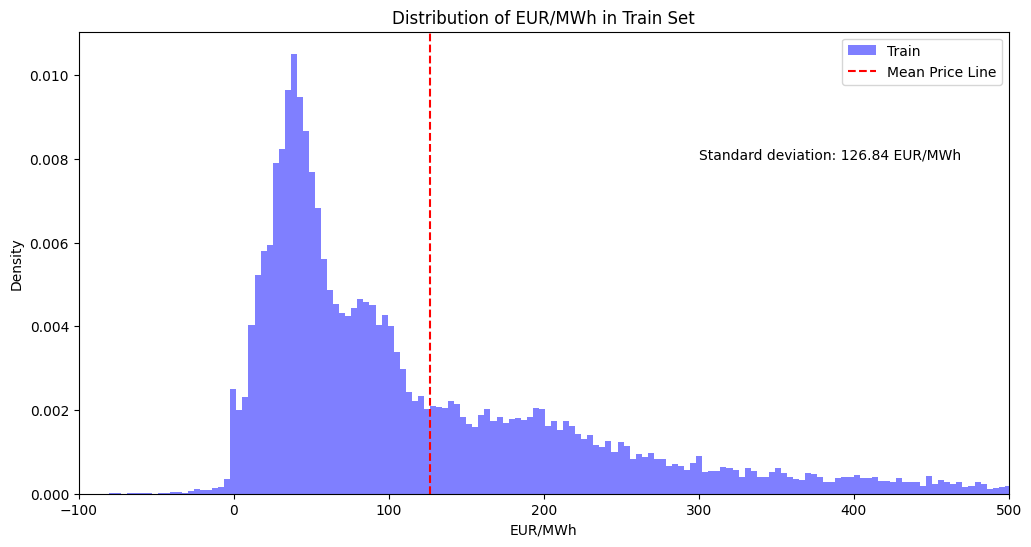

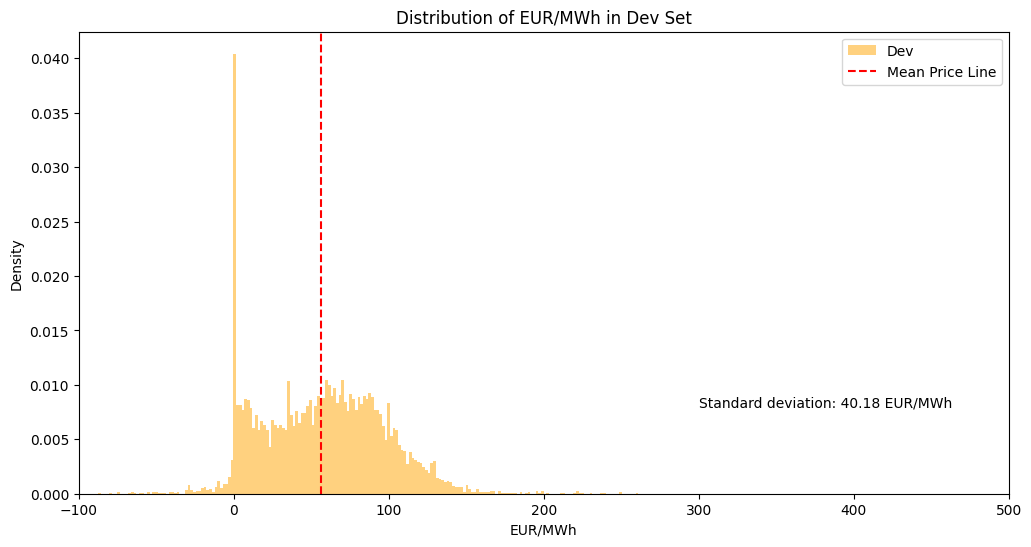

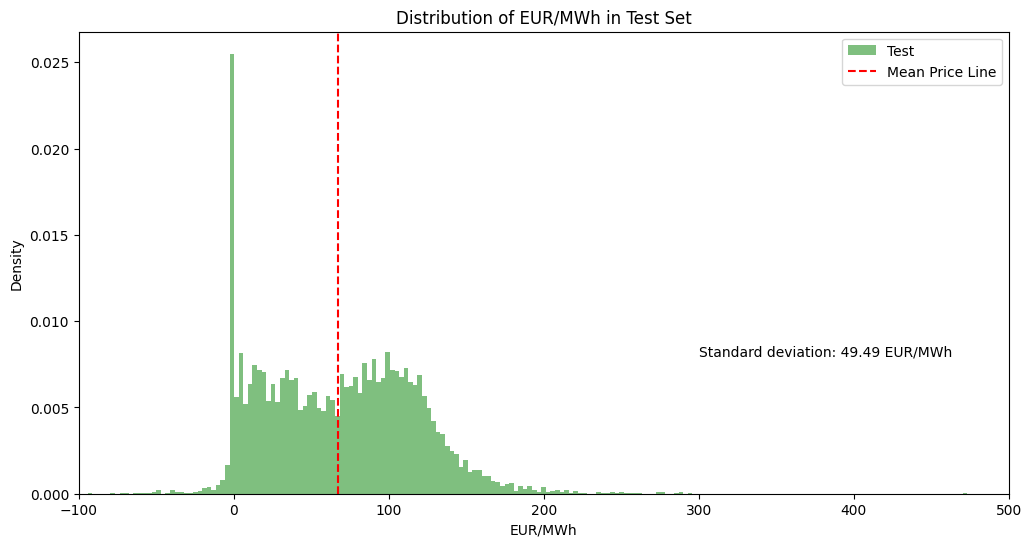

In [8]:
#Plot the distributions of train, dev, test sets on separate histograms
plt.figure(figsize=(12, 6))
plt.hist(train_df_FR['EUR/MWh'], bins=800, alpha=0.5, label='Train', color='blue', density=True)
plt.axvline(x=np.mean(train_df_FR['EUR/MWh']), color='red', linestyle='--', label='Mean Price Line')
plt.text(300, 0.008, "Standard deviation: {:.2f} EUR/MWh".format(np.std(train_df_FR['EUR/MWh'])), fontsize=10, color='black')
plt.title('Distribution of EUR/MWh in Train Set')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.xlim(-100, 500)
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(dev_df_FR['EUR/MWh'], bins=200, alpha=0.5, label='Dev', color='orange', density=True)
plt.axvline(x=np.mean(dev_df_FR['EUR/MWh']), color='red', linestyle='--', label='Mean Price Line')
plt.text(300, 0.008, "Standard deviation: {:.2f} EUR/MWh".format(np.std(dev_df_FR['EUR/MWh'])), fontsize=10, color='black')
plt.title('Distribution of EUR/MWh in Dev Set')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.xlim(-100, 500)
plt.legend()
plt.show()
plt.figure(figsize=(12, 6))
plt.hist(test_df_FR['EUR/MWh'], bins=200, alpha=0.5, label='Test', color='green', density=True)
plt.axvline(x=np.mean(test_df_FR['EUR/MWh']), color='red', linestyle='--', label='Mean Price Line')
plt.text(300, 0.008, "Standard deviation: {:.2f} EUR/MWh".format(np.std(test_df_FR['EUR/MWh'])), fontsize=10, color='black')
plt.xlabel('EUR/MWh')
plt.ylabel('Density')
plt.title('Distribution of EUR/MWh in Test Set')
plt.xlim(-100, 500)
plt.legend()
plt.show()


In [ ]:
#Compute and print the mean and std of the target variable in each set
print("Train Set - Mean EUR/MWh:", train_df_FR['EUR/MWh'].mean(), "Std EUR/MWh:", train_df_FR['EUR/MWh'].std())
print("Dev Set - Mean EUR/MWh:", dev_df_FR['EUR/MWh'].mean(), "Std EUR/MWh:", dev_df_FR['EUR/MWh'].std())
print("Test Set - Mean EUR/MWh:", test_df_FR['EUR/MWh'].mean(), "Std EUR/MWh:", test_df_FR['EUR/MWh'].std())

Train Set - Mean EUR/MWh: 126.53131089280555 Std EUR/MWh: 126.8393230781919
Dev Set - Mean EUR/MWh: 56.4391356337547 Std EUR/MWh: 40.183551538285
Test Set - Mean EUR/MWh: 67.37815326633165 Std EUR/MWh: 49.49166329861799


In [ ]:
#Compute and print the quantiles (5%,95%) of the target variable in each set
print("Train Set - 5% Quantile EUR/MWh:", train_df_FR['EUR/MWh'].quantile(0.05), "95% Quantile EUR/MWh:", train_df_FR['EUR/MWh'].quantile(0.95))
print("Dev Set - 5% Quantile EUR/MWh:", dev_df_FR['EUR/MWh'].quantile(0.05), "95% Quantile EUR/MWh:", dev_df_FR['EUR/MWh'].quantile(0.95))
print("Test Set - 5% Quantile EUR/MWh:", test_df_FR['EUR/MWh'].quantile(0.05), "95% Quantile EUR/MWh:", test_df_FR['EUR/MWh'].quantile(0.95))

Train Set - 5% Quantile EUR/MWh: 14.02 95% Quantile EUR/MWh: 395.9049999999996
Dev Set - 5% Quantile EUR/MWh: 0.0 95% Quantile EUR/MWh: 121.22
Test Set - 5% Quantile EUR/MWh: -0.01 95% Quantile EUR/MWh: 144.83


In [ ]:


def compute_shift_metrics(df, target_col="EUR/MWh"):
    y = df[target_col].values

    # Basic stats
    mean_y = np.mean(y)
    std_y = np.std(y)
    q05 = np.percentile(y, 5)
    q95 = np.percentile(y, 95)
    median_y = np.median(y)

    # Diff (volatility)
    diffs = np.abs(np.diff(y))              # <-- THIS IS WHAT YOU ASKED FOR
    mean_diff = np.mean(diffs)
    std_diff = np.std(diffs)

    # Naive-1 baseline error
    naive1_err = np.mean(np.abs(y[1:] - y[:-1]))

    return {
        "mean": mean_y,
        "std": std_y,
        "median": median_y,
        "q05": q05,
        "q95": q95,
        "mean_diff": mean_diff,
        "std_diff": std_diff,
        "naive1_error": naive1_err
    }


In [ ]:
train_stats = compute_shift_metrics(train_df_FR, target_col="EUR/MWh")
dev_stats   = compute_shift_metrics(dev_df_FR,   target_col="EUR/MWh")
test_stats  = compute_shift_metrics(test_df_FR,  target_col="EUR/MWh")

print("TRAIN:", train_stats)
print("DEV:", dev_stats)
print("TEST:", test_stats)


TRAIN: {'mean': 126.53131089280555, 'std': 126.83749065635867, 'median': 81.35, 'q05': 14.02, 'q95': 395.9049999999996, 'mean_diff': 10.72179693143402, 'std_diff': 23.9934496951648, 'naive1_error': 10.72179693143402}
DEV: {'mean': 56.4391356337547, 'std': 40.18126337659204, 'median': 57.62, 'q05': 0.0, 'q95': 121.22, 'mean_diff': 9.461421412300684, 'std_diff': 9.720529685390241, 'naive1_error': 9.461421412300684}
TEST: {'mean': 67.37815326633165, 'std': 49.48883706081203, 'median': 68.34, 'q05': -0.01, 'q95': 144.83, 'mean_diff': 11.305427755568246, 'std_diff': 11.780202476169961, 'naive1_error': 11.305427755568246}


In [ ]:
import ruptures as rpt
import numpy as np
import pandas as pd

def detect_regime_changes(df, column="price", model="rbf", penalty=5):
    """
    Detect regime changes in a price series using ruptures.
    
    Parameters:
        df      : pandas DataFrame with a datetime index or a 'date' column
        column  : target variable (price)
        model   : cost model ("rbf" detects mean+variance shifts)
        penalty : controls sensitivity (lower → more breaks)
        
    Returns:
        break_dates: list of dates where regimes change
    """

    # Ensure sorted by date
    df = df.sort_values("date").reset_index(drop=True)

    # Extract the series
    series = df[column].values.reshape(-1, 1)

    # Run change point detection
    algo = rpt.Pelt(model=model).fit(series)
    breaks = algo.predict(pen=penalty)

    # Convert indices → dates (remove final index which is len(series))
    breakpoints = [df['date'].iloc[b-1] for b in breaks[:-1]]

    return breakpoints


In [ ]:
breaks = detect_regime_changes(all_data, column="EUR/MWh")

print("Regime change dates:")
for b in breaks:
    print(b)


MemoryError: Unable to allocate 10.1 GiB for an array with shape (1359628731,) and data type float64

In [ ]:
import matplotlib.pyplot as plt
import ruptures as rpt

def plot_regimes(df, column="price", model="rbf", penalty=5):
    df = df.sort_values("date").reset_index(drop=True)
    series = df[column].values

    algo = rpt.Pelt(model=model).fit(series)
    breaks = algo.predict(pen=penalty)

    rpt.display(series, breaks, figsize=(18,6))
    plt.title("Detected Regime Changes (mean + variance)")
    plt.show()
plot_regimes(all_data, column="EUR/MWh", model="rbf", penalty=5)